# Analyse jeu de données + data viz

## import des données et description générale

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/avis_40k.csv', sep=';', header=0)

print('chargement des données et description rapide.')

display(df.head())
display(df.info())
display(df.describe())


chargement des données et description rapide.


,auteur,note,titre,commentaire,date_experience,date_avis,url,texteServiceReply,dateServiceReply,dataServiceReply
0,FREDERIC (Bordeaux),4,Produit conforme,Produit conforme. La description du contenue e...,"February 13, 2026",A day ago,https://www.trustpilot.com/review/oscaro.com,NaN,NaN,NaN
1,Patrice,5,Comportement professionnel,NaN,"February 11, 2026",3 days ago,https://www.trustpilot.com/review/oscaro.com,NaN,NaN,NaN
2,Client daniel,4,R.A.S,..............R.A.S.........,"January 31, 2026",3 days ago,https://www.trustpilot.com/review/oscaro.com,NaN,NaN,NaN
3,Derek Mcmillan,5,Excellent.,NaN,"February 4, 2026","Feb 4, 2026",https://www.trustpilot.com/review/oscaro.com,Reply from Oscaro,"Feb 5, 2026","Bonjour Derek, Je vous remercie pour votre ret..."
4,GM,4,Tres bien mais attention bien scotcher…,Tres bien mais attention bien scotcher les col...,"January 30, 2026","Feb 1, 2026",https://www.trustpilot.com/review/oscaro.com,Reply from Oscaro,"Feb 3, 2026","Bonjour Grégoire , Je vous remercie pour votre..."


<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   auteur             40000 non-null  str  
 1   note               40000 non-null  int64
 2   titre              40000 non-null  str  
 3   commentaire        36225 non-null  str  
 4   date_experience    40000 non-null  str  
 5   date_avis          40000 non-null  str  
 6   url                40000 non-null  str  
 7   texteServiceReply  33146 non-null  str  
 8   dateServiceReply   33146 non-null  str  
 9   dataServiceReply   33146 non-null  str  
dtypes: int64(1), str(9)
memory usage: 22.2 MB


None

,note
count,40000.00000
mean,4.02915
std,1.40819
min,1.00000
25%,3.00000
50%,5.00000
75%,5.00000
max,5.00000


## traitement des Na et suppression de variables inutiles

traitement des NaN
3775
pourcentage Na parmi les avis: 9.4375
            auteur  note                           titre commentaire  \
1          Patrice     5      Comportement professionnel         NaN   
3   Derek Mcmillan     5                      Excellent.         NaN   
7     Masnou Bruno     5      Super.....................         NaN   
16          Anouar     5                  Good good good         NaN   
19           Aslan     1  Nulle je déconseille set sites         NaN   

      date_experience     date_avis  \
1   February 11, 2026    3 days ago   
3    February 4, 2026   Feb 4, 2026   
7    January 15, 2026  Jan 16, 2026   
16  December 15, 2025  Dec 17, 2025   
19  November 27, 2025  Nov 27, 2025   

                                             url  texteServiceReply  \
1   https://www.trustpilot.com/review/oscaro.com                NaN   
3   https://www.trustpilot.com/review/oscaro.com  Reply from Oscaro   
7   https://www.trustpilot.com/review/oscaro.com  Reply f

Text(0.5, 1.0, 'Proportion de NaN parmi les avis clients')

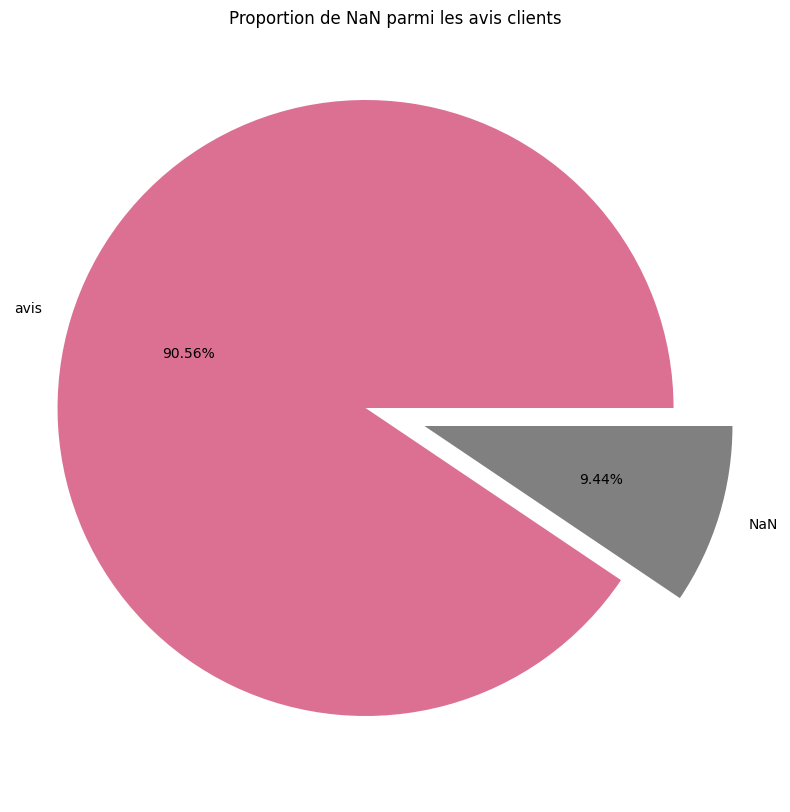

In [2]:
print('traitement des NaN')

print(df['commentaire'].isna().sum())
print('pourcentage Na parmi les avis:', df['commentaire'].isna().sum()/len(df['commentaire'])*100)
print(df[df['commentaire'].isna()].head())


plt.figure(figsize=(10,10))
plt.pie(df["commentaire"].isna().value_counts(normalize=True),
            labels=['avis', 'NaN'],
            explode=[0.1, 0.1],
            autopct="%0.2f%%",
            colors=["palevioletred", "grey"])
plt.title('Proportion de NaN parmi les avis clients')

In [3]:
df['commentaire'] = df['commentaire'].fillna(df['titre']) # remplacement na par titre
df[['commentaire', 'auteur', 'date_avis']] = df[['commentaire', 'auteur', 'date_avis']].drop_duplicates()
df = df.drop('date_avis', axis=1) # suppression date avis, on garde uniquement date experience
df = df.drop('texteServiceReply', axis=1) # suppression de la variable car n'apporte pas d'info
df = df.drop('url', axis = 1)
df = df.drop('dateServiceReply', axis = 1)

display(df.info())
display(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   auteur            39948 non-null  str  
 1   note              40000 non-null  int64
 2   titre             40000 non-null  str  
 3   commentaire       39948 non-null  str  
 4   date_experience   40000 non-null  str  
 5   dataServiceReply  33146 non-null  str  
dtypes: int64(1), str(5)
memory usage: 17.2 MB


None

,auteur,note,titre,commentaire,date_experience,dataServiceReply
0,FREDERIC (Bordeaux),4,Produit conforme,Produit conforme. La description du contenue e...,"February 13, 2026",NaN
1,Patrice,5,Comportement professionnel,Comportement professionnel,"February 11, 2026",NaN
2,Client daniel,4,R.A.S,..............R.A.S.........,"January 31, 2026",NaN
3,Derek Mcmillan,5,Excellent.,Excellent.,"February 4, 2026","Bonjour Derek, Je vous remercie pour votre ret..."
4,GM,4,Tres bien mais attention bien scotcher…,Tres bien mais attention bien scotcher les col...,"January 30, 2026","Bonjour Grégoire , Je vous remercie pour votre..."


## Traitement de la langue dans le corpus d'avis

In [4]:
from langdetect import detect
from langdetect import DetectorFactory
DetectorFactory.seed = 34

def to_detect(text_i): # détection de la langue
    try :
        return detect(text_i)
    except:
        return ('NA')

df["lang"] = df["commentaire"].apply(lambda x: to_detect(x))
print(df['lang'].value_counts())
print(df['lang'].describe(include='O'))




lang
fr    38261
ca      360
es      316
en      289
de      128
it      123
pt      122
ro      105
NA       78
nl       47
vi       25
lv       18
id       16
af       16
hu       13
sk       11
et       10
fi        9
so        7
sv        7
pl        6
tl        6
da        5
lt        4
sq        4
tr        3
no        3
cy        3
bg        1
ru        1
cs        1
sw        1
hr        1
Name: count, dtype: int64
count     40000
unique       33
top          fr
freq      38261
Name: lang, dtype: object


In [ ]:
display(df.info())

In [5]:
df.to_csv('data/40k_langdetect.csv')

In [57]:
test = pd.read_csv('data/40k_langdetect.csv', sep=',', header=0, index_col=0)
test.head()

,auteur,note,titre,commentaire,date_experience,dataServiceReply,lang
0,FREDERIC (Bordeaux),4,Produit conforme,Produit conforme. La description du contenue e...,"February 13, 2026",NaN,fr
1,Patrice,5,Comportement professionnel,Comportement professionnel,"February 11, 2026",NaN,fr
2,Client daniel,4,R.A.S,..............R.A.S.........,"January 31, 2026",NaN,hu
3,Derek Mcmillan,5,Excellent.,Excellent.,"February 4, 2026","Bonjour Derek, Je vous remercie pour votre ret...",ca
4,GM,4,Tres bien mais attention bien scotcher…,Tres bien mais attention bien scotcher les col...,"January 30, 2026","Bonjour Grégoire , Je vous remercie pour votre...",fr


Text(0, 0.5, "nombre d'occurences")

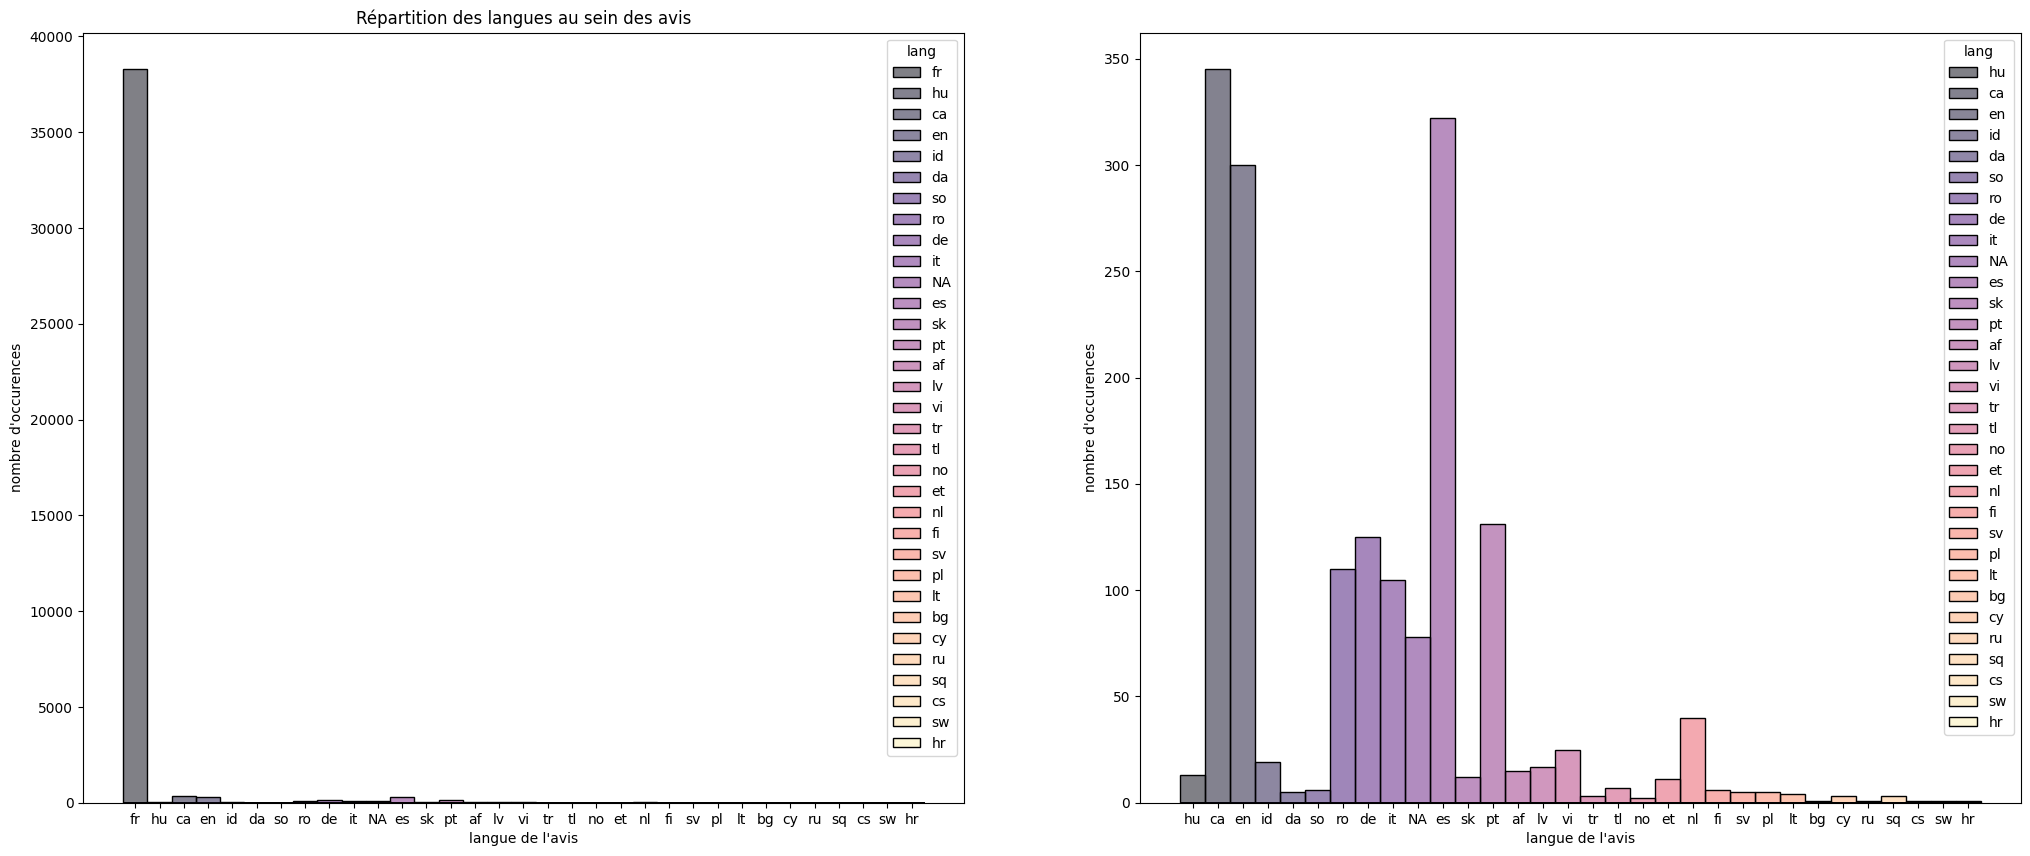

In [6]:

plt.figure(figsize=(25,10))

plt.subplot(121)
plt.title('Répartition des langues au sein des avis')
sns.histplot(data=df, x= 'lang', hue='lang', palette='magma')
plt.xlabel('langue de l\'avis')
plt.ylabel('nombre d\'occurences')
plt.subplot(122)
sns.histplot(data=df.loc[df['lang']!='fr'], x= 'lang', hue='lang', palette='magma')
plt.xlabel('langue de l\'avis')
plt.ylabel('nombre d\'occurences')

In [5]:

#df = df.drop('lang', axis=1)
df = df[df["lang"] == "fr"] # on conserve uniquement les avis en français
df = df.dropna(subset=['commentaire'])
df.head()
df.info()

<class 'pandas.DataFrame'>
Index: 38261 entries, 0 to 39999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   auteur            38261 non-null  str  
 1   note              38261 non-null  int64
 2   titre             38261 non-null  str  
 3   commentaire       38261 non-null  str  
 4   date_experience   38261 non-null  str  
 5   dataServiceReply  31736 non-null  str  
 6   lang              38261 non-null  str  
dtypes: int64(1), str(6)
memory usage: 17.3 MB


## création nouvelles variables

In [6]:

month_to_number = {'January' : 1, 'February' : 2, 'March' : 3, 'April' : 4, 'May' : 5, 'June' : 6, 'July' : 7, 'August' : 8, 'September' : 9, 'October' : 10, 'November' : 11, 'December' : 12}

df['date_experience_year'] = df['date_experience'].str[-4:] # transformation variable date_experience en 2 variables: année et mois
df['date_experience_month'] = df['date_experience'].replace(month_to_number, regex=True).astype(int)
df['date_experience_year'] = df['date_experience_year'].astype(int)
df = df.drop('date_experience', axis=1)

# création comm_reply : fusion avis + réponse entreprise
df['comm_reply'] = np.where(df['dataServiceReply'].isna() == False, df['commentaire'] + df['dataServiceReply'], df['commentaire'])

# création length_comm : taille de l'avis
df['length_comm'] = df['commentaire'].apply(lambda x: len(x))



df.info()
df.head()

<class 'pandas.DataFrame'>
Index: 38261 entries, 0 to 39999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   auteur                 38261 non-null  str  
 1   note                   38261 non-null  int64
 2   titre                  38261 non-null  str  
 3   commentaire            38261 non-null  str  
 4   dataServiceReply       31736 non-null  str  
 5   lang                   38261 non-null  str  
 6   date_experience_year   38261 non-null  int64
 7   date_experience_month  38261 non-null  int64
 8   comm_reply             38261 non-null  str  
 9   length_comm            38261 non-null  int64
dtypes: int64(4), str(6)
memory usage: 30.5 MB


,auteur,note,titre,commentaire,dataServiceReply,lang,date_experience_year,date_experience_month,comm_reply,length_comm
0,FREDERIC (Bordeaux),4,Produit conforme,Produit conforme. La description du contenue e...,NaN,fr,2026,2,Produit conforme. La description du contenue e...,136
1,Patrice,5,Comportement professionnel,Comportement professionnel,NaN,fr,2026,2,Comportement professionnel,26
4,GM,4,Tres bien mais attention bien scotcher…,Tres bien mais attention bien scotcher les col...,"Bonjour Grégoire , Je vous remercie pour votre...",fr,2026,1,Tres bien mais attention bien scotcher les col...,100
5,eric petitot,4,Piece conforme mais la gaine de…,Piece conforme mais la gaine de protection sur...,"Bonjour Eric, Je vous remercie pour votre reto...",fr,2026,1,Piece conforme mais la gaine de protection sur...,114
9,Moha,5,Enjoliveur par choc,"Simple, rapide et efficace.","Bonjour Mohamed, Je vous remercie pour votre r...",fr,2026,1,"Simple, rapide et efficace.Bonjour Mohamed, Je...",27


## Proportion finale Na

In [7]:



print("Evaluation de la part des données manquantes: ", end="\n\n")

for i in df.columns :
    print(i)
    print(df[i].isna().sum()/len(df[i])*100, end="\n\n")


df.info()
df.head()

Evaluation de la part des données manquantes: 

auteur
0.0

note
0.0

titre
0.0

commentaire
0.0

dataServiceReply
17.053919134366588

lang
0.0

date_experience_year
0.0

date_experience_month
0.0

comm_reply
0.0

length_comm
0.0

<class 'pandas.DataFrame'>
Index: 38261 entries, 0 to 39999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   auteur                 38261 non-null  str  
 1   note                   38261 non-null  int64
 2   titre                  38261 non-null  str  
 3   commentaire            38261 non-null  str  
 4   dataServiceReply       31736 non-null  str  
 5   lang                   38261 non-null  str  
 6   date_experience_year   38261 non-null  int64
 7   date_experience_month  38261 non-null  int64
 8   comm_reply             38261 non-null  str  
 9   length_comm            38261 non-null  int64
dtypes: int64(4), str(6)
memory usage: 30.5 MB


,auteur,note,titre,commentaire,dataServiceReply,lang,date_experience_year,date_experience_month,comm_reply,length_comm
0,FREDERIC (Bordeaux),4,Produit conforme,Produit conforme. La description du contenue e...,NaN,fr,2026,2,Produit conforme. La description du contenue e...,136
1,Patrice,5,Comportement professionnel,Comportement professionnel,NaN,fr,2026,2,Comportement professionnel,26
4,GM,4,Tres bien mais attention bien scotcher…,Tres bien mais attention bien scotcher les col...,"Bonjour Grégoire , Je vous remercie pour votre...",fr,2026,1,Tres bien mais attention bien scotcher les col...,100
5,eric petitot,4,Piece conforme mais la gaine de…,Piece conforme mais la gaine de protection sur...,"Bonjour Eric, Je vous remercie pour votre reto...",fr,2026,1,Piece conforme mais la gaine de protection sur...,114
9,Moha,5,Enjoliveur par choc,"Simple, rapide et efficace.","Bonjour Mohamed, Je vous remercie pour votre r...",fr,2026,1,"Simple, rapide et efficace.Bonjour Mohamed, Je...",27


In [77]:
df.to_csv('data/40k_final_process.csv')

## Distribution des notes et de la taille des commentaires

Text(0.5, 1.0, 'taille médiane des commentaires en fonction de la note')

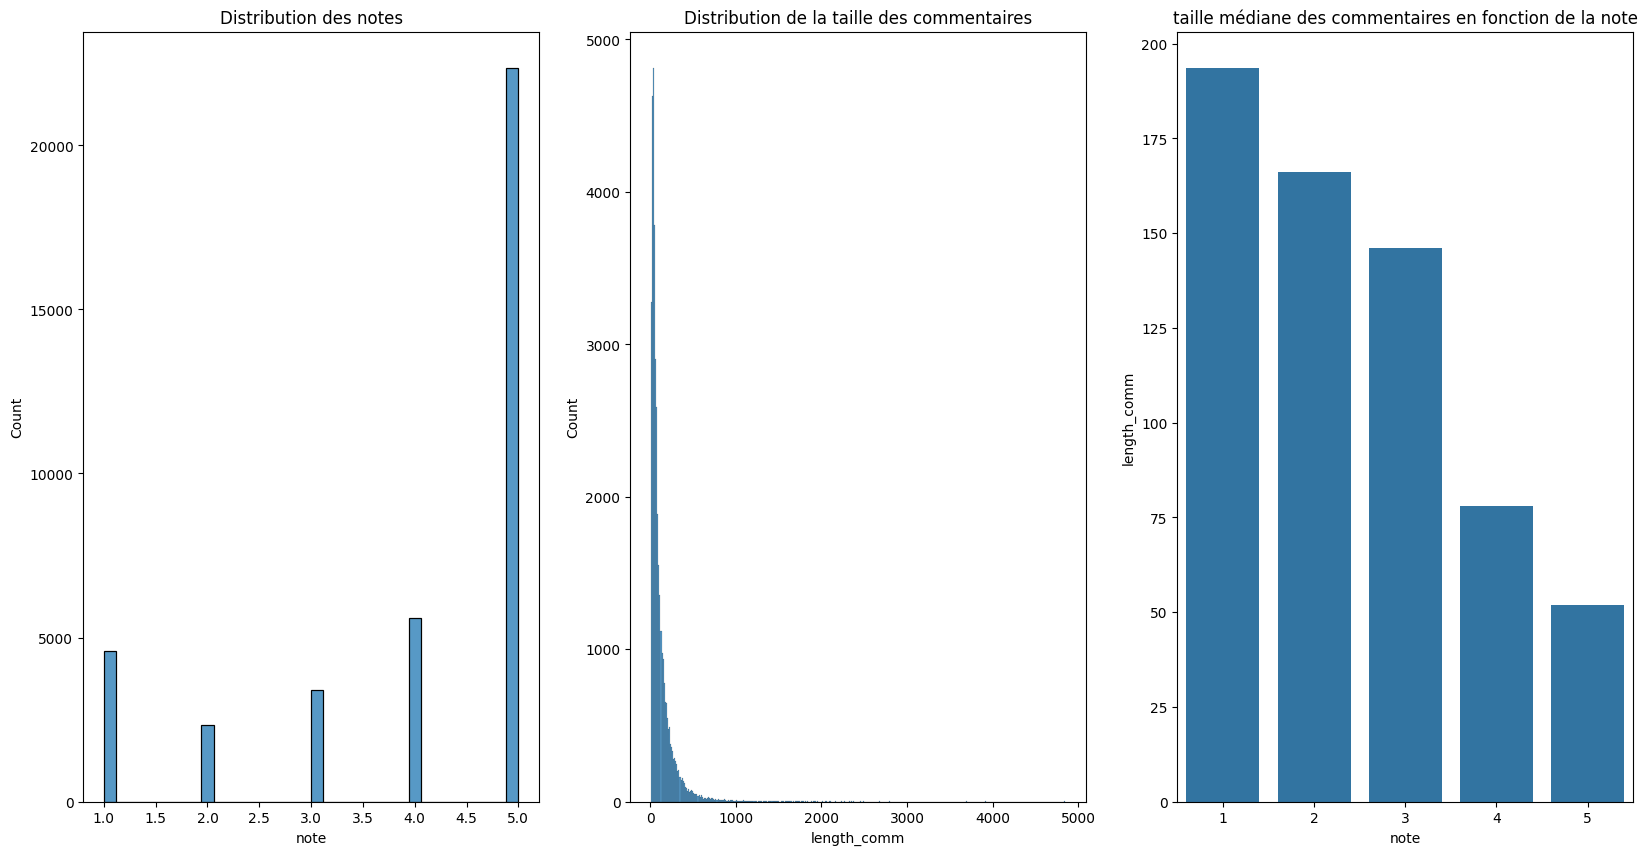

In [10]:


plt.figure(figsize=(20,10))

plt.subplot(131)

sns.histplot(df['note'])
plt.title('Distribution des notes')

plt.subplot(132)

sns.histplot(df['length_comm'])
plt.title('Distribution de la taille des commentaires')

plt.subplot(133)

sns.barplot(data= df[['note','length_comm']].groupby('note').median(), x='note', y='length_comm')
plt.title('taille médiane des commentaires en fonction de la note')


## Corrélation taille commentaire / note

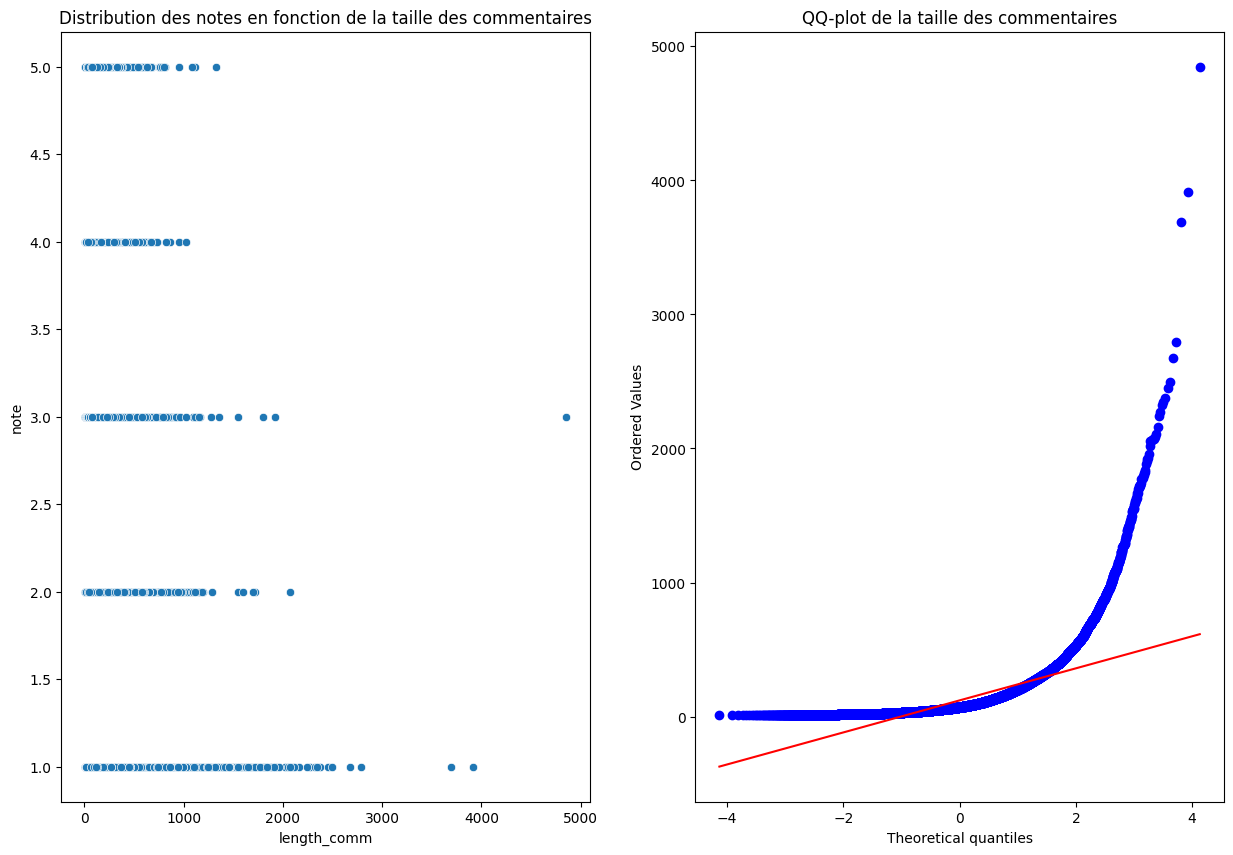

                 note  length_comm
note         1.000000    -0.463254
length_comm -0.463254     1.000000
normalité des données, shapiro's p.value: 1.5681870901549819e-77
pearson correlation coef: -0.4632544270482017
pearson correlation p.value: 0.0
kendall correlation coef: -0.37380965310547937
kendall correlation p.value: 0.0


In [11]:
import scipy.stats as ss

plt.figure(figsize=(15,10))
plt.subplot(1,2,1)
sns.scatterplot(x=df['length_comm'], y=df['note'])
plt.title('Distribution des notes en fonction de la taille des commentaires')
plt.subplot(122)
ss.probplot(df['length_comm'], plot=plt)
plt.title('QQ-plot de la taille des commentaires')
plt.show()



#plt.subplot(223)
#sns.lmplot(x='length_comm', y='note', data=df, )

print(df[['note', 'length_comm']].corr())

print('normalité des données, shapiro\'s p.value:', ss.shapiro(df['length_comm'].head(5000))[1])
print('pearson correlation coef:', ss.pearsonr(df['length_comm'], df['note'])[0])
print('pearson correlation p.value:', ss.pearsonr(df['length_comm'], df['note'])[1])
print('kendall correlation coef:', ss.kendalltau(df['length_comm'], df['note'])[0])
print('kendall correlation p.value:', ss.kendalltau(df['length_comm'], df['note'])[1])

## Répartition temporelle du jeu de données

date_experience_month
5     0.130708
11    0.104336
8     0.102925
6     0.100991
10    0.098691
7     0.098037
1     0.086407
12    0.086171
9     0.074018
4     0.065367
2     0.045529
3     0.006822
Name: proportion, dtype: float64

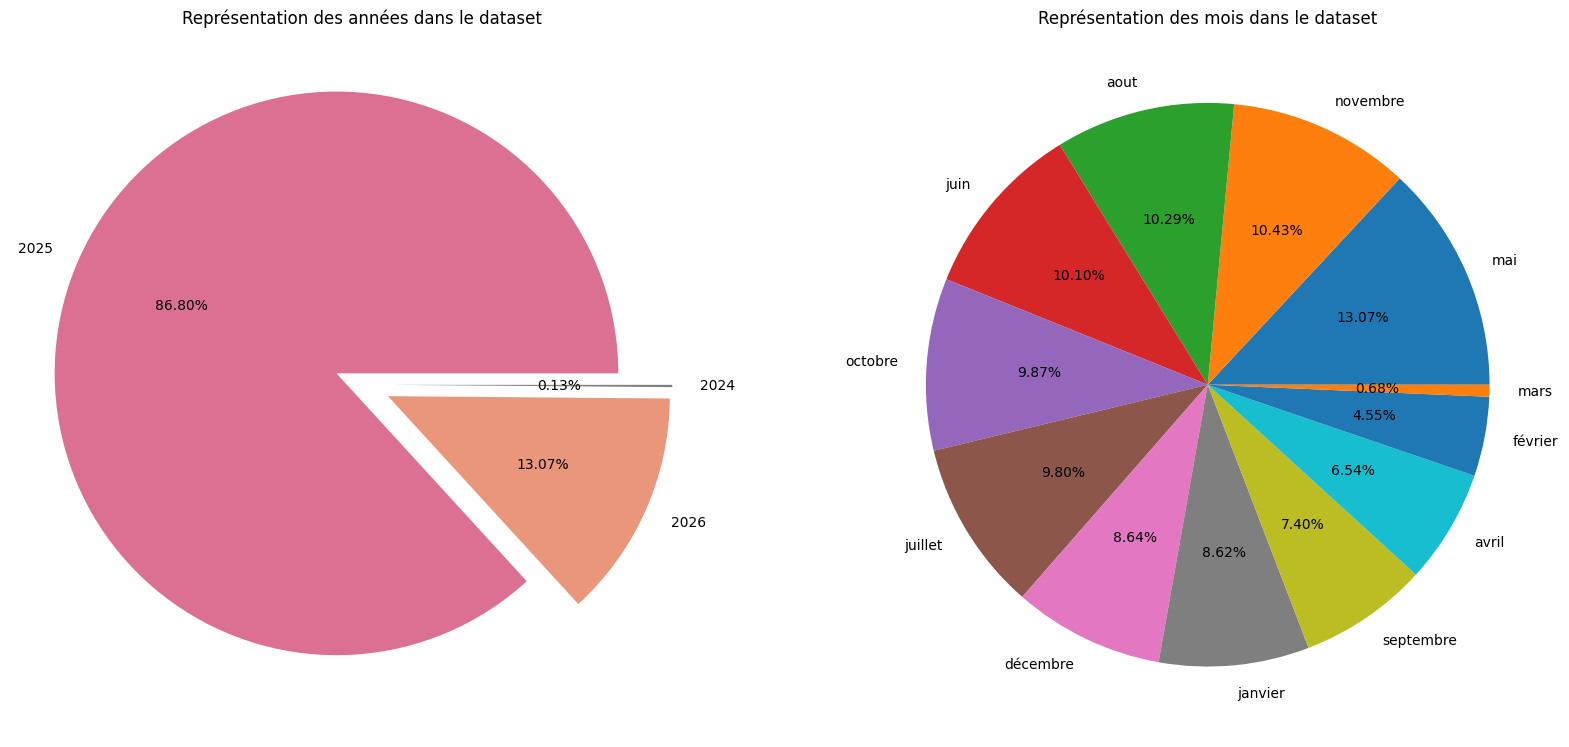

In [8]:
plt.figure(figsize=(20,10))

plt.subplot(121)

plt.pie(df["date_experience_year"].value_counts(normalize=True),
            labels=['2025', '2026', '2024'],
            explode=[0.1, 0.1, 0.1],
            autopct="%0.2f%%",
            colors=["palevioletred", "darksalmon", "grey"])
plt.title('Représentation des années dans le dataset')

plt.subplot(122)

plt.pie(df["date_experience_month"].value_counts(normalize=True),
            labels=['mai', 'novembre', 'aout', 'juin', 'octobre', 'juillet', 'décembre', 'janvier', 'septembre', 'avril', 'février', 'mars'],
            #explode=[0.1, 0.1, 0.1],
            autopct="%0.2f%%")
            #colors=["palevioletred", "darksalmon", "grey"])
plt.title('Représentation des mois dans le dataset')


df["date_experience_month"].value_counts(normalize=True)

## Light cleaning 

In [9]:
import re

def clean_text(text):
    try:
        text = re.sub(r"http\S+", "", text)        # URLs
        text = re.sub(r"<.*?>", "", text)          # HTML
        text = re.sub(r"\S+@\S+", "", text)        # emails
        text = re.sub(r"\s+", " ", text).strip()   # espaces multiples
    except TypeError :
        text = np.nan
    return text


df['commentaire'] = df['commentaire'].apply(lambda x: clean_text(x))
df['dataServiceReply'] = df['dataServiceReply'].apply(lambda x: clean_text(x))





df.info()
df.head()

<class 'pandas.DataFrame'>
Index: 38261 entries, 0 to 39999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   auteur                 38261 non-null  str  
 1   note                   38261 non-null  int64
 2   titre                  38261 non-null  str  
 3   commentaire            38261 non-null  str  
 4   dataServiceReply       31736 non-null  str  
 5   lang                   38261 non-null  str  
 6   date_experience_year   38261 non-null  int64
 7   date_experience_month  38261 non-null  int64
 8   comm_reply             38261 non-null  str  
 9   length_comm            38261 non-null  int64
dtypes: int64(4), str(6)
memory usage: 30.5 MB


,auteur,note,titre,commentaire,dataServiceReply,lang,date_experience_year,date_experience_month,comm_reply,length_comm
0,FREDERIC (Bordeaux),4,Produit conforme,Produit conforme. La description du contenue e...,NaN,fr,2026,2,Produit conforme. La description du contenue e...,136
1,Patrice,5,Comportement professionnel,Comportement professionnel,NaN,fr,2026,2,Comportement professionnel,26
4,GM,4,Tres bien mais attention bien scotcher…,Tres bien mais attention bien scotcher les col...,"Bonjour Grégoire , Je vous remercie pour votre...",fr,2026,1,Tres bien mais attention bien scotcher les col...,100
5,eric petitot,4,Piece conforme mais la gaine de…,Piece conforme mais la gaine de protection sur...,"Bonjour Eric, Je vous remercie pour votre reto...",fr,2026,1,Piece conforme mais la gaine de protection sur...,114
9,Moha,5,Enjoliveur par choc,"Simple, rapide et efficace.","Bonjour Mohamed, Je vous remercie pour votre r...",fr,2026,1,"Simple, rapide et efficace.Bonjour Mohamed, Je...",27


## WordClouds

In [14]:
import re
import nltk
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

# Télécharger les ressources nécessaires (à faire une seule fois)
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download('punkt_tab')

# Exemple de texte
#text = " ".join(df['commentaire'])
text = " ".join(df[df['note'] == 1]['commentaire'].to_list())
text_to_emb = " ".join(df_fr['commentaire'].to_list())
# 1️⃣ Lowercase
text = text.lower()
text_to_emb = text_to_emb.lower()
# 2️⃣ Suppression ponctuation et chiffres
text = re.sub(r"[^a-zàâäéèêëîïôöùûüç\s]", "", text)
text_to_emb = re.sub(r"[^a-zàâäéèêëîïôöùûüç\s]", "", text_to_emb)
# 3️⃣ Tokenisation
tokens = word_tokenize(text)
tokens_to_emb = word_tokenize(text_to_emb)
# 4️⃣ Suppression des stopwords
stop_words = set(stopwords.words("french"))
tokens = [word for word in tokens if word not in stop_words]
tokens_to_emb = [word for word in tokens_to_emb if word not in stop_words]
# 5️⃣ Lemmatisation
lemmatizer = WordNetLemmatizer()
tokens = [lemmatizer.lemmatize(word) for word in tokens]
tokens_to_emb = [lemmatizer.lemmatize(word) for word in tokens_to_emb]
# 6️⃣ Rejointure
processed_text = " ".join(tokens)

# 7️⃣ Wordcloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(processed_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

[nltk_data] Downloading package punkt to /home/robin/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/robin/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/robin/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/robin/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


NameError: name 'df_fr' is not defined

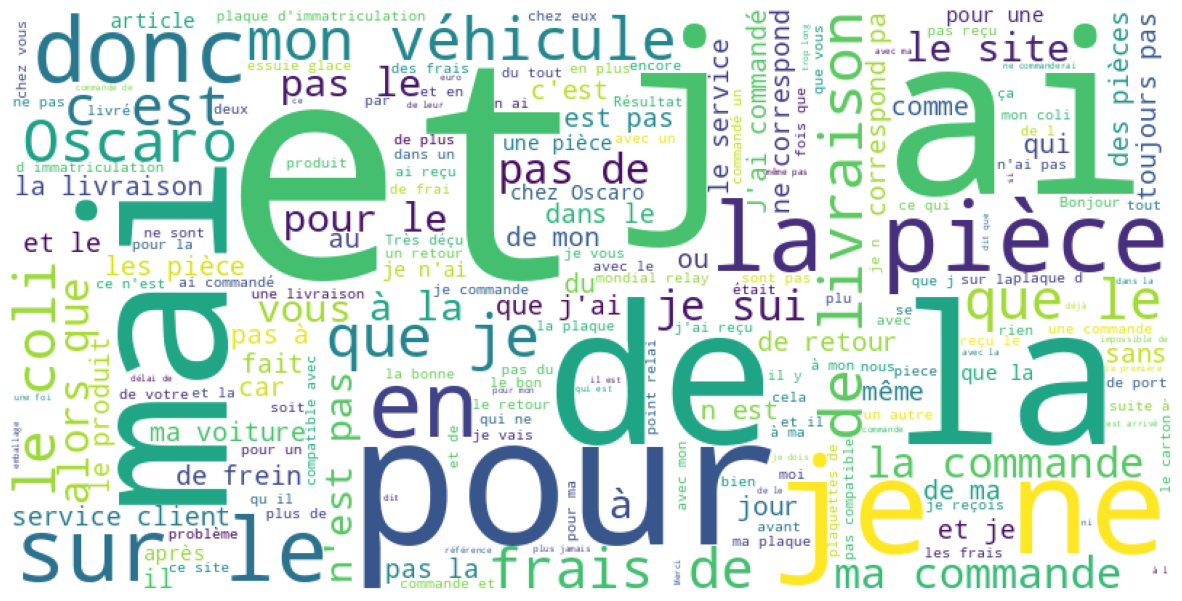

In [58]:
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud



corpus = df['commentaire']
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(corpus)
features = vectorizer.get_feature_names_out()

text = " ".join(df[df['note'] == 1]['commentaire'].to_list())
#text = " ".join(df['commentaire'].to_list())
# 2️⃣ Générer le word cloud
wc = WordCloud(width=800, height=400, background_color="white")
wc.generate(text)


plt.figure(figsize=(15,10))

plt.imshow(wc)
plt.axis("off")
plt.show()



# Clustering
## Embeddings + fine - tuning avec LoRA

### charger le modèle + LoRA

In [14]:
from sentence_transformers import SentenceTransformer
from peft import LoraConfig, get_peft_model

model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-mpnet-base-v2")

# backbone transformer
transformer = model._first_module().auto_model

# config LoRA
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["query", "value"],
    lora_dropout=0.1,
    bias="none"
)

# inject LoRA
transformer = get_peft_model(transformer, lora_config)

# ⚡ FIX : FORCER return_dict=False pour compatibilité SentenceTransformers
transformer.config.return_dict = False

# réinjection dans SentenceTransformer
model._first_module().auto_model = transformer

/home/robin/projets/Supply-Chain-Reviews/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1860.67it/s, Materializing param=pooler.dense.weight]                               
XLMRobertaModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### Générer des paires positives

In [162]:
from transformers import MarianMTModel, MarianTokenizer

# modèles de traduction
model_name_fr_en = "Helsinki-NLP/opus-mt-fr-en"
model_name_en_fr = "Helsinki-NLP/opus-mt-en-fr"

tokenizer_fr_en = MarianTokenizer.from_pretrained(model_name_fr_en)
model_fr_en = MarianMTModel.from_pretrained(model_name_fr_en)

tokenizer_en_fr = MarianTokenizer.from_pretrained(model_name_en_fr)
model_en_fr = MarianMTModel.from_pretrained(model_name_en_fr)

/home/robin/projets/Supply-Chain-Reviews/.venv/lib/python3.13/site-packages/transformers/models/marian/tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")
Loading weights: 100%|██████████| 258/258 [00:00<00:00, 678.13it/s, Materializing param=model.shared.weight]                                  
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


In [61]:
def back_translate(text):
    if not text or len(text.strip()) == 0:
        return text

    # FR → EN
    batch = tokenizer_fr_en(
        [text],
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=512
    )

    translated = model_fr_en.generate(**batch)
    en_text = tokenizer_fr_en.batch_decode(translated, skip_special_tokens=True)[0]

    # EN → FR
    batch = tokenizer_en_fr(
        [en_text],
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=512
    )

    translated = model_en_fr.generate(**batch)
    fr_text = tokenizer_en_fr.batch_decode(translated, skip_special_tokens=True)[0]

    return fr_text

In [62]:
from sentence_transformers import util

model = SentenceTransformer('sentence-transformers/distiluse-base-multilingual-cased-v2')
#model = SentenceTransformer('sentence-transformers/all-MiniLM-L12-v2')

def is_good_pair(text, augmented, threshold=0.7):
    emb1 = model.encode(text, normalize_embeddings=True)
    emb2 = model.encode(augmented, normalize_embeddings=True)
    
    score = util.cos_sim(emb1, emb2)
    return score > threshold

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 584.20it/s, Materializing param=transformer.layer.5.sa_layer_norm.weight]   


### création des paires (atention c'est très long!!)

In [65]:

filtered_pairs = []

long_texts = df.loc[df['length_comm'] > 75]
short_texts = df.loc[df['length_comm'] <= 75]



total_sample_size = int(len(df) * 0.3)

# Répartition 50% longs, 50% courts
long_sample_size = total_sample_size // 2
short_sample_size = total_sample_size - long_sample_size

long_sample = long_texts.sample(n=long_sample_size, random_state=42)
short_sample = short_texts.sample(n=short_sample_size, random_state=42)

df_sample = pd.concat([long_sample, short_sample]).sample(frac=1, random_state=42)

# convertir en liste
corpus_sample = df_sample['commentaire'].to_list()

print(f"Taille du corpus échantillonné : {len(corpus_sample)}")

for text in corpus_sample:
    aug = back_translate(text)
    
    if is_good_pair(text, aug):
        filtered_pairs.append((text, aug))

Taille du corpus échantillonné : 11476


In [118]:
### exporter filtered pairs pour être sûr de ne pas les perdre

import csv

# filtered_pairs = [('texte1', 'texte2'), ('texte3', 'texte4'), ...]
with open("filtered_pairs.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    # optionnel : écrire un header
    writer.writerow(["text1", "text2"])
    writer.writerows(filtered_pairs)

In [15]:
import csv

filtered_pairs = []

with open("filtered_pairs.csv", "r", encoding="utf-8") as f:
    reader = csv.reader(f)
    
    next(reader)  # skip header
    
    for row in reader:
        text1, text2 = row
        filtered_pairs.append((text1, text2))

In [16]:
from sentence_transformers import InputExample

train_examples = [
    InputExample(texts=[t1, t2])
    for t1, t2 in filtered_pairs
]

In [33]:
#print(type(train_examples[0])) #### vérification 
model.encode(["test"])
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

0.auto_model.embeddings.word_embeddings.weight
0.auto_model.embeddings.token_type_embeddings.weight
0.auto_model.embeddings.LayerNorm.weight
0.auto_model.embeddings.LayerNorm.bias
0.auto_model.embeddings.position_embeddings.weight
0.auto_model.encoder.layer.0.attention.self.query.weight
0.auto_model.encoder.layer.0.attention.self.query.bias
0.auto_model.encoder.layer.0.attention.self.key.weight
0.auto_model.encoder.layer.0.attention.self.key.bias
0.auto_model.encoder.layer.0.attention.self.value.weight
0.auto_model.encoder.layer.0.attention.self.value.bias
0.auto_model.encoder.layer.0.attention.output.dense.weight
0.auto_model.encoder.layer.0.attention.output.dense.bias
0.auto_model.encoder.layer.0.attention.output.LayerNorm.weight
0.auto_model.encoder.layer.0.attention.output.LayerNorm.bias
0.auto_model.encoder.layer.0.intermediate.dense.weight
0.auto_model.encoder.layer.0.intermediate.dense.bias
0.auto_model.encoder.layer.0.output.dense.weight
0.auto_model.encoder.layer.0.output.dens

In [170]:
filtered_pairs

[('J’ai passé commande de plusieurs articles un samedi : 4 essuie-glaces Deux disques de freins Un jeu de plaquettes et Deux roulements de roue J’ai été livré en trois fois 1)les roulements les plaquettes et 3 essuie-glaces 2)un essuie-glace 3)Enfin les disques 10 jours après la commande À chaque fois obligé de me déplacer au point relais à 20 km de chez moi Contacté Oscaro qui n’a comme réponse que « il faut attendre » Très déçu ! À la commande tout est disponible et donc pouvait être expédié en un seul colis J’ai également un retour dont j’attends le remboursement depuis 2 semaines Appelé Oscaro : Le colis est perdu on fait une enquête ! A l’heure d’aujourd’hui toujours en attente de remboursement Le service Oscaro régresse de plus en plus Même pas la courtoisie d’un geste commercial comme la livraison gratuite à la prochaine commande Je met 2 étoiles pour rester correct et pour le bon fonctionnement d’y il a maintenant plusieurs années déjà Franchement déçu',
  'J\'ai passé commande

In [132]:
model

SentenceTransformer(
  (0): Transformer({'max_seq_length': 128, 'do_lower_case': False, 'architecture': 'PeftModel'})
  (1): Pooling({'word_embedding_dimension': 768, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
)

In [18]:
from sentence_transformers import losses

train_loss = losses.MultipleNegativesRankingLoss(model)

In [19]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    train_examples,
    batch_size=32,
    shuffle=True
)

In [20]:
warmup_steps = int(len(train_dataloader) * 0.1)

In [21]:
import torch, gc

gc.collect()
torch.cuda.empty_cache()

model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    epochs=10,
    warmup_steps=warmup_steps,
    show_progress_bar=True,
    use_amp=True
)

/home/robin/projets/Supply-Chain-Reviews/.venv/lib/python3.13/site-packages/torch/cuda/__init__.py:1007: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()
/home/robin/projets/Supply-Chain-Reviews/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
500,0.055926
1000,0.019997
1500,0.013809
2000,0.010366
2500,0.009489
3000,0.008450
3500,0.009761


In [36]:
model.max_seq_length = 512
embeddings_paraphrase_lora = model.encode(df['commentaire'].tolist(), normalize_embeddings=True)

In [ ]:
model.save('paraphrase_lora_10epoch')

#np.save('labels_paraphrase_lora_1epoch.npy', lab)

In [44]:
np.save('data_final/embeddings_paraphrase_lora_10epoch.npy', embeddings_paraphrase_lora)
np.save('data_final/embeddings_paraphrase.npy', embeddings_paraphrase)


In [90]:
import torch
from transformers import AutoTokenizer, AutoModel
from peft import PeftModel
from sentence_transformers import SentenceTransformer, models


tokenizer = AutoTokenizer.from_pretrained(
"sentence-transformers/paraphrase-multilingual-mpnet-base-v2"
)
base_model = AutoModel.from_pretrained(
"sentence-transformers/paraphrase-multilingual-mpnet-base-v2"
)

model = PeftModel.from_pretrained(base_model, "paraphrase_lora_10epoch")
model = model.merge_and_unload()
model.save_pretrained("final_lora")
model = AutoModel.from_pretrained("final_lora")

word_embedding_model = models.Transformer("final_lora")

pooling_model = models.Pooling(
    word_embedding_model.get_word_embedding_dimension(),
    pooling_mode_mean_tokens=True
)

model = SentenceTransformer(modules=[word_embedding_model, pooling_model])

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2295.63it/s, Materializing param=pooler.dense.weight]                               
XLMRobertaModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2506.12it/s, Materializing param=pooler.dense.weight]                               


In [65]:
torch.save(model.state_dict(), "model_lora_10epoch.pth")

### export pour la visualization

In [92]:
np.savez("labels_embeddings_paraphrase_hdbscan_3d.npz", embeddings=embeddings_paraphrase_3d, labels=labels_nolora_agglo_postprocess)
np.savez("labels_embeddings_paraphrase_kmeans_3d.npz", embeddings=embeddings_paraphrase_3d, labels=labels_nolora_kmeans)
np.savez("labels_embeddings_paraphrase_lora_hdbscan_3d.npz", embeddings=embeddings_paraphrase_lora_3d, labels=labels_lora_agglo_postprocess)
np.savez("labels_embeddings_paraphrase_lora_kmeans_3d.npz", embeddings=embeddings_paraphrase_lora_3d, labels=labels_lora_kmeans)



In [95]:
np.savez("labels_embeddings_paraphrase_hdbscan.npz", embeddings=X_reduced_nolora, labels=labels_nolora_agglo_postprocess)
np.savez("labels_embeddings_paraphrase_kmeans.npz", embeddings=X_reduced_nolora_kmeans, labels=labels_nolora_kmeans)
np.savez("labels_embeddings_paraphrase_lora_hdbscan.npz", embeddings=X_reduced_lora, labels=labels_lora_agglo_postprocess)
np.savez("labels_embeddings_paraphrase_lora_kmeans.npz", embeddings=X_reduced_lora_kmeans, labels=labels_lora_kmeans)



In [ ]:
from sentence_transformers import SentenceTransformer

model_minilm = SentenceTransformer('sentence-transformers/all-MiniLM-L12-v2')

#print(df['commentaire'].tolist())

embeddings_minilm = model_minilm.encode(df['commentaire'].tolist(), normalize_embeddings=True)




/home/robin/projets/Supply-Chain-Reviews/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 702.14it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [85]:
df_final['note'].value_counts()

note
5    22350
4     5601
1     4598
3     3407
2     2322
Name: count, dtype: int64

In [ ]:
## Test du clustering à partir d'un nettoyage complet comme pour les wordClouds 
# -> temps de clustering excessivement long et très mauvais résultats avec des centaines de clusters obtenus malgrès les mêmes paramètres
# qu'utilisés précèdemment avec le soft cleaning 

#from sentence_transformers import SentenceTransformer

#model_minilm_fr = SentenceTransformer('sentence-transformers/all-MiniLM-L12-v2')

#print(df['commentaire'].tolist())

#embeddings_minilm_fr = model_minilm_fr.encode(df_fr['commentaire'].tolist())
#embeddings_minilm_fr = model_minilm_fr.encode(tokens_to_emb)

/home/robin/projets/Supply-Chain-Reviews/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 800.49it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [37]:
model_paraphrase = SentenceTransformer('sentence-transformers/paraphrase-multilingual-mpnet-base-v2')

#print(df['commentaire'].tolist())

embeddings_paraphrase = model_paraphrase.encode(df['commentaire'].tolist(), normalize_embeddings=True)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3049.65it/s, Materializing param=pooler.dense.weight]                               
XLMRobertaModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
#model_paraphrase_fr = SentenceTransformer('sentence-transformers/paraphrase-multilingual-mpnet-base-v2')

#print(df['commentaire'].tolist())

#embeddings_paraphrase_fr = model_paraphrase_fr.encode(df_fr['commentaire'].tolist())
#embeddings_paraphrase_fr = model_paraphrase_fr.encode(tokens_to_emb)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 828.99it/s, Materializing param=pooler.dense.weight]                               
XLMRobertaModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
#from sentence_transformers import SentenceTransformer

#model_camembert = SentenceTransformer('Lajavaness/sentence-camembert-large')

#print(df['commentaire'].tolist())

#embeddings_camembert = model_camembert.encode(tokens_to_emb)

Loading weights: 100%|██████████| 391/391 [00:01<00:00, 352.78it/s, Materializing param=pooler.dense.weight]                               


## réduction de dimensions et clustering

In [ ]:
from sklearn.cluster import HDBSCAN
import umap
import joblib

# export UMAP pipeline paraphrase + umap + hdbscan + agglo + postprocess
reducer_paraphrase_hdbscan = umap.UMAP(
    n_neighbors=5,
    min_dist=0,
    n_components=5,
    metric="cosine",
    random_state=42
)
reducer_paraphrase_hdbscan.fit_transform(embeddings_paraphrase)
joblib.dump(reducer_paraphrase_hdbscan, "umap_paraphrase_hdbscan.pkl")

# export UMAP pipeline paraphrase + umap + kmeans
reducer_paraphrase_kmeans = umap.UMAP(
    n_neighbors=10,
    min_dist=0,
    n_components=5,
    metric="cosine",
    random_state=42
)
reducer_paraphrase_kmeans.fit_transform(embeddings_paraphrase)
joblib.dump(reducer_paraphrase_kmeans, "umap_paraphrase_kmeans.pkl")

# export UMAP pipeline paraphrase + lora + umap + hdbscan + agglo + postprocess
reducer_paraphrase_lora_hdbscan = umap.UMAP(
    n_neighbors=15,
    min_dist=0,
    n_components=10,
    metric="cosine",
    random_state=42
)
reducer_paraphrase_lora_hdbscan.fit_transform(embeddings_paraphrase_lora)
joblib.dump(reducer_paraphrase_lora_hdbscan, "umap_paraphrase_lora_hdbscan.pkl")

# export UMAP pipeline paraphrase + lora + umap + kmeans
reducer_paraphrase_lora_kmeans = umap.UMAP(
    n_neighbors=15,
    min_dist=0.05,
    n_components=5,
    metric="cosine",
    random_state=42
)
reducer_paraphrase_lora_kmeans.fit_transform(embeddings_paraphrase_lora)
joblib.dump(reducer_paraphrase_lora_kmeans, "umap_paraphrase_lora_kmeans.pkl")

/home/robin/projets/Supply-Chain-Reviews/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/robin/projets/Supply-Chain-Reviews/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/robin/projets/Supply-Chain-Reviews/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/robin/projets/Supply-Chain-Reviews/.venv/lib/python3.13/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/home/robin/projets/Supply-Chain-Reviews/.venv/lib/python3.13/site-packages/

['umap_paraphrase_lora_kmeans.pkl']

In [79]:
from sklearn.cluster import KMeans
clusterer_lora = KMeans(n_clusters=10, random_state=42, n_init="auto")
clusterer_lora.fit_predict(X_reduced_lora_kmeans)
joblib.dump(clusterer_lora, "kmeans_paraphrase_lora.pkl")

clusterer_nolora = KMeans(n_clusters=10, random_state=42, n_init="auto")
clusterer_nolora.fit_predict(X_reduced_nolora_kmeans)
joblib.dump(clusterer_nolora, "kmeans_paraphrase.pkl")


['kmeans_paraphrase.pkl']

In [27]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=6, random_state=42, n_init="auto")
#labels_kmean_minilm = kmeans.fit_predict(X_minilm)
labels_kmean_paraphrase = kmeans.fit_predict(X_paraphrase)


## évaluation des clusters

In [24]:
def plot(X, labels, probabilities=None, parameters=None, ground_truth=False, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 4))
    labels = labels if labels is not None else np.ones(X.shape[0])
    probabilities = probabilities if probabilities is not None else np.ones(X.shape[0])
    # Black removed and is used for noise instead.
    unique_labels = set(labels)
    colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
    # The probability of a point belonging to its labeled cluster determines
    # the size of its marker
    proba_map = {idx: probabilities[idx] for idx in range(len(labels))}
    for k, col in zip(unique_labels, colors):
        if k == -1:
            # Black used for noise.
            col = [0, 0, 0, 1]

        class_index = (labels == k).nonzero()[0]
        for ci in class_index:
            ax.plot(
                X[ci, 0],
                X[ci, 1],
                "x" if k == -1 else "o",
                markerfacecolor=tuple(col),
                markeredgecolor="k",
                markersize=4 if k == -1 else 1 + 5 * proba_map[ci],
            )
    n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
    preamble = "True" if ground_truth else "Estimated"
    title = f"{preamble} number of clusters: {n_clusters_}"
    if parameters is not None:
        parameters_str = ", ".join(f"{k}={v}" for k, v in parameters.items())
        title += f" | {parameters_str}"
    ax.set_title(title)
    plt.tight_layout()

   



In [132]:
 plot(embeddings_paraphrase, labels=labels_paraphrase)

NameError: name 'labels_paraphrase' is not defined

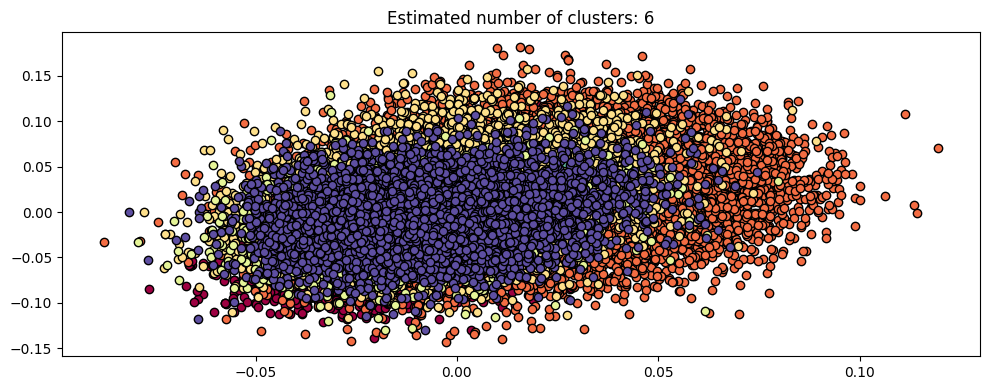

In [29]:
 plot(embeddings_paraphrase, labels=labels_kmean_paraphrase)

In [89]:

df_final = pd.read_csv('data/40k_final_process.csv', sep=',', header=0, index_col=0) # chargement des données après preprocessing final


df_viz = pd.DataFrame({
    "text": df['commentaire'],
    "cluster": labels_lora_kmeans
})

print(df_viz['cluster'].value_counts())

print(df_viz['cluster'].shape)
#sns.countplot(df_viz.loc[df_viz['cluster'] != -1, 'cluster'])

cluster
5    5291
6    4494
0    4180
8    3879
2    3794
4    3472
9    3457
1    3305
7    3259
3    3130
Name: count, dtype: int64
(38261,)


In [74]:
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
from sklearn.metrics import silhouette_score
from collections import Counter


custom_stop = ['livraison', 'commande', 'très', 'rapide']

# retirer le bruit HDBSCAN (-1)
df_viz = df_viz[df_viz.cluster != -1]

cluster_names = {}



for cluster_id in df_viz.cluster.unique():

    docs = df_viz[df_viz.cluster == cluster_id]["text"]
    #seuil= len(docs)/3  # filtre de fréquence d'occurence supplémentaire
    #custom_stop = Counter(docs)
    #custom_stop = [w for w, c in custom_stop.items() if c > seuil]
    #print(f"custom_stop: {custom_stop}")
    vectorizer = TfidfVectorizer(
        stop_words=stopwords.words("french") + custom_stop,
        #max_features=20,
        ngram_range=(1,2)
    )

    X = vectorizer.fit_transform(docs)

    scores = X.mean(axis=0).A1
    words = vectorizer.get_feature_names_out()

    ranking = sorted(
        zip(words, scores),
        key=lambda x: x[1],
        reverse=True
    )

    keywords = [w for w,_ in ranking[:5]]

    cluster_names[cluster_id] = " / ".join(keywords)

for cluster in cluster_names:
    print(f'Cluster: {cluster} \t size: {len(df_viz[df_viz['cluster'] == cluster])}')
    print(f'keywords: \t{cluster_names[cluster]}')

mask = labels_lora_kmeans != -1
if len(set(labels_lora_kmeans[mask])) > 1:
    score = silhouette_score(X_reduced_lora_kmeans[mask], labels_lora_kmeans[mask])   

#silhouette = silhouette_score(X_reduced_lora, labels_lora)
print(f'silhouette score: {score}')



Cluster: 6 	 size: 4494
keywords: 	conforme / prix / bien / pièces / produit
Cluster: 5 	 size: 5291
keywords: 	conforme / parfait / rapidité / bien / produit
Cluster: 4 	 size: 3472
keywords: 	conforme / produit / prix / bien / pièces
Cluster: 1 	 size: 3305
keywords: 	conforme / bien / efficace / rapidité / parfait
Cluster: 0 	 size: 4180
keywords: 	colis / oscaro / plus / pièces / pièce
Cluster: 3 	 size: 3130
keywords: 	conforme / produit / prix / bien / produit conforme
Cluster: 8 	 size: 3879
keywords: 	conforme / colis / bien / pièces / produit
Cluster: 2 	 size: 3794
keywords: 	pièces / bien / colis / prix / conforme
Cluster: 9 	 size: 3457
keywords: 	conforme / prix / pièces / bien / produit
Cluster: 7 	 size: 3259
keywords: 	conforme / prix / produit / bien / pièces
silhouette score: 0.30431249737739563


In [56]:
from sklearn.metrics.pairwise import cosine_similarity

def get_representative_texts(embeddings, corpus, labels, top_k=3):
    cluster_repr = {}
    
    for cluster_id in set(labels):
        if cluster_id == -1:
            continue
        
        idx = [i for i in range(len(labels)) if labels[i] == cluster_id]
        cluster_emb = embeddings[idx]
        
        centroid = cluster_emb.mean(axis=0).reshape(1, -1)
        sim = cosine_similarity(cluster_emb, centroid).ravel()
        
        top_idx = np.argsort(sim)[-top_k:][::-1]
        
        cluster_repr[cluster_id] = [corpus[idx[i]] for i in top_idx]
    
    return cluster_repr

In [71]:
cluster_repr = get_representative_texts(embeddings_paraphrase_lora, df['commentaire'].to_list(), labels_lora_kmeans)
for i in cluster_repr:
    print(f'cluster {i}: {cluster_repr[i]}')

cluster 0: ['Déçu de ma commande J ai rentré ma plaque d immatriculation pour être sur d avoir les bons essuies glace et impossible de les monter Demande si échange possible , oui mais il faut payer 9,90 pour le retour alors que j ai payé à peine 5 euros de livraison', "Ce n'est pas la première fois que je commande chez vous, mais là j'ai eu un souci avec le bidon d'huile qui a une fuite au bouchon. Le carton intérieur a bien bu ! J'espère que ça ne ce reproduira pas, mais ça ne m'empêchera de recommander une autre fois.", "J'ai commandé des vérins de coffre en précisant la marque le type et, j'ai pris selon que vous me proposer il ne s'adapte pas à mon véhicule. J'ai renvoyé les pièces et on m'a facturer les frais de retour Je ne sais pas si a l'avenir je recommanderais chez vous"]
cluster 1: ['Livraison un peu longue', 'Rapidité de la livraison', 'Pas les bonnes pièces']
cluster 2: ['La butée d’embrayage était défaillante, elle avait un défaut de fabrication, oscaro n’a pas voulu me 

## optimisation UMAP + HDBSCAN

In [38]:
import numpy as np
from sklearn.metrics import silhouette_score
from itertools import product
from sklearn.cluster import HDBSCAN
from umap import UMAP

def evaluate_clustering(X, labels):
    # enlever le bruit
    mask = labels != -1
    
    if len(set(labels[mask])) < 2:
        return -1  # pas assez de clusters
    
    return silhouette_score(X[mask], labels[mask])

scores_umap = {}

def optimize_umap(embeddings):
    param_grid = {
        "n_neighbors": [5, 10, 15],
        "min_dist": [0.0, 0.05, 0.1],
        "n_components": [5, 10]
    }

    best_score = -1
    best_params = None
    best_embedding = None

    for n_neighbors, min_dist, n_components in product(
        param_grid["n_neighbors"],
        param_grid["min_dist"],
        param_grid["n_components"]
    ):
        umap_model = UMAP(
            n_neighbors=n_neighbors,
            min_dist=min_dist,
            n_components=n_components,
            metric="cosine",
            random_state=42
        )

        X_reduced = umap_model.fit_transform(embeddings)

        # clustering temporaire (valeur fixe)
        clusterer = HDBSCAN(min_cluster_size=30, metric="euclidean")
        labels = clusterer.fit_predict(X_reduced)

        score = evaluate_clustering(X_reduced, labels)
        scores_umap['n_neighbors_' + str(n_neighbors) + "_min_dist_" + str(min_dist) + '_n_components_' + str(n_components)] = score

        if score > best_score:
            best_score = score
            best_params = (n_neighbors, min_dist, n_components)
            best_embedding = X_reduced

    print("Best UMAP:", best_params, "score:", best_score)
    return best_embedding, best_params

scores_hdbscan = {}

def optimize_hdbscan(X_reduced):
    min_cluster_sizes = [10, 20, 30, 50, 100, 150]

    best_score = -1
    best_param = None
    best_labels = None

    for mcs in min_cluster_sizes:
        clusterer = HDBSCAN(
            min_cluster_size=mcs,
            metric="euclidean"
        )

        labels = clusterer.fit_predict(X_reduced)

        score = evaluate_clustering(X_reduced, labels)
        scores_hdbscan['min_cluster_size_' + str(mcs) ] = score

        if score > best_score:
            best_score = score
            best_param = mcs
            best_labels = labels

    print("Best HDBSCAN min_cluster_size:", best_param, "score:", best_score)
    return best_labels, best_param

In [39]:
from sklearn.cluster import KMeans

scores_kmeans = {}

def optimize_umap_kmeans(embeddings):
    param_grid = {
        "n_neighbors": [5, 10, 15],
        "min_dist": [0.0, 0.05, 0.1],
        "n_components": [5, 10]
    }

    best_score = -1
    best_params = None
    best_embedding = None

    for n_neighbors, min_dist, n_components in product(
        param_grid["n_neighbors"],
        param_grid["min_dist"],
        param_grid["n_components"]
    ):
        umap_model = UMAP(
            n_neighbors=n_neighbors,
            min_dist=min_dist,
            n_components=n_components,
            metric="cosine",
            random_state=42
        )

        X_reduced = umap_model.fit_transform(embeddings)

        # clustering temporaire (valeur fixe)
        clusterer = KMeans(n_clusters=10, random_state=42, n_init="auto")
        labels = clusterer.fit_predict(X_reduced)

        score = evaluate_clustering(X_reduced, labels)
        scores_kmeans['n_neighbors_' + str(n_neighbors) + "_min_dist_" + str(min_dist) + '_n_components_' + str(n_components)] = score

        if score > best_score:
            best_score = score
            best_params = (n_neighbors, min_dist, n_components)
            best_embedding = X_reduced
            best_labels = labels

    print("Best UMAP + KMEANS:", best_params, "score:", best_score)
    return best_labels, best_embedding, best_params

In [40]:
# 1️⃣ UMAP
X_reduced_lora, best_umap_params = optimize_umap(embeddings_paraphrase_lora)

# 2️⃣ HDBSCAN
labels_lora, best_mcs = optimize_hdbscan(X_reduced_lora)

/home/robin/projets/Supply-Chain-Reviews/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/robin/projets/Supply-Chain-Reviews/.venv/lib/python3.13/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/home/robin/projets/Supply-Chain-Reviews/.venv/lib/python3.13/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/home/robin/projets/Supply-Chain-Reviews/.venv/lib/python3.13/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` wi

Best UMAP: (15, 0.0, 10) score: 0.9459966421127319


/home/robin/projets/Supply-Chain-Reviews/.venv/lib/python3.13/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/home/robin/projets/Supply-Chain-Reviews/.venv/lib/python3.13/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/home/robin/projets/Supply-Chain-Reviews/.venv/lib/python3.13/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/home/robin/projets/Supply-Chain-Reviews/.venv/lib/python3.13/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10.

Best HDBSCAN min_cluster_size: 20 score: 0.9461327195167542


In [41]:
# 1️⃣ UMAP
X_reduced_nolora, best_umap_params = optimize_umap(embeddings_paraphrase)

# 2️⃣ HDBSCAN
labels_nolora, best_mcs = optimize_hdbscan(X_reduced_nolora)

/home/robin/projets/Supply-Chain-Reviews/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/robin/projets/Supply-Chain-Reviews/.venv/lib/python3.13/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/home/robin/projets/Supply-Chain-Reviews/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/robin/projets/Supply-Chain-Reviews/.venv/lib/python3.13/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/home/robin/projets/Supply-Chain-Reviews/.venv/lib/python3.13/

Best UMAP: (5, 0.0, 5) score: 0.5811600089073181


/home/robin/projets/Supply-Chain-Reviews/.venv/lib/python3.13/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/home/robin/projets/Supply-Chain-Reviews/.venv/lib/python3.13/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/home/robin/projets/Supply-Chain-Reviews/.venv/lib/python3.13/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/home/robin/projets/Supply-Chain-Reviews/.venv/lib/python3.13/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10.

Best HDBSCAN min_cluster_size: 10 score: 0.6324224472045898


In [42]:
labels_lora_kmeans, X_reduced_lora_kmeans, best_umap_params_kmeans = optimize_umap_kmeans(embeddings_paraphrase_lora)



/home/robin/projets/Supply-Chain-Reviews/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/robin/projets/Supply-Chain-Reviews/.venv/lib/python3.13/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/home/robin/projets/Supply-Chain-Reviews/.venv/lib/python3.13/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/home/robin/projets/Supply-Chain-Reviews/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_stat

Best UMAP + KMEANS: (15, 0.05, 5) score: 0.30431249737739563


In [43]:
labels_nolora_kmeans, X_reduced_nolora_kmeans, best_umap_params_kmeans_nolora = optimize_umap_kmeans(embeddings_paraphrase)



/home/robin/projets/Supply-Chain-Reviews/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/robin/projets/Supply-Chain-Reviews/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/robin/projets/Supply-Chain-Reviews/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/robin/projets/Supply-Chain-Reviews/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/robin/projets/Supply-Chain-Reviews/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism

Best UMAP + KMEANS: (10, 0.0, 5) score: 0.44435593485832214


In [45]:
import numpy as np ### calcul des centroids

def compute_centroids(embeddings, labels):
    unique_labels = [l for l in set(labels) if l != -1]  # ignorer le bruit
    centroids = {}
    for l in unique_labels:
        centroids[l] = embeddings[labels == l].mean(axis=0)
    return centroids

In [46]:
from sklearn.metrics.pairwise import cosine_similarity

centroids = compute_centroids(embeddings_paraphrase, labels_nolora)
centroid_keys = list(centroids.keys())
centroid_matrix = np.stack([centroids[k] for k in centroid_keys])
sim_matrix = cosine_similarity(centroid_matrix)

In [47]:
centroids_lora = compute_centroids(embeddings_paraphrase_lora, labels_lora)
centroid_lora_keys = list(centroids_lora.keys())
centroid_lora_matrix = np.stack([centroids_lora[k] for k in centroid_lora_keys])
sim_matrix_lora = cosine_similarity(centroid_lora_matrix)

In [48]:
from sklearn.cluster import AgglomerativeClustering

agglo = AgglomerativeClustering(
    n_clusters=10, 
    metric='cosine', 
    linkage='average'
)
new_cluster_ids = agglo.fit_predict(centroid_matrix)
new_cluster_ids_lora = agglo.fit_predict(centroid_lora_matrix)

In [89]:
threshold = 0.75  # fusionner si très similaires
cosine_labels = labels_lora.copy()

for i in range(len(centroid_keys)):
    for j in range(i+1, len(centroid_keys)):
        if sim_matrix[i,j] > threshold:
            cosine_labels[labels_lora == centroid_keys[j]] = centroid_keys[i]  # fusionner dans le cluster i

In [49]:
agglo_labels_nolora = labels_nolora.copy()
for old_label, new_label in zip(centroid_keys, new_cluster_ids):
    agglo_labels_nolora[labels_nolora == old_label] = new_label

In [50]:
agglo_labels_lora = labels_lora.copy()
for old_label, new_label in zip(centroid_lora_keys, new_cluster_ids_lora):
    agglo_labels_lora[labels_lora == old_label] = new_label

In [51]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def postprocess_clusters(embeddings, labels, similarity_threshold=0.6, verbose=True):
    """
    Nettoie et réassigne les points bruités après HDBSCAN.
    
    Args:
        embeddings (np.ndarray): matrice des embeddings (n_samples x dim)
        labels (np.ndarray): labels HDBSCAN (-1 = bruit)
        similarity_threshold (float): seuil cosine pour réassignation du bruit
        verbose (bool): afficher résumé
    
    Returns:
        np.ndarray: labels post-processed
    """
    
    new_labels = labels.copy()
    
    # indices
    clustered_idx = labels != -1
    noise_idx = labels == -1
    
    if np.sum(noise_idx) == 0:
        if verbose:
            print("Aucun bruit détecté.")
        return new_labels
    
    clustered_emb = embeddings[clustered_idx]
    clustered_labels = labels[clustered_idx]
    noise_emb = embeddings[noise_idx]
    
    # calculer similarité cosine entre bruit et points clusterisés
    sim = cosine_similarity(noise_emb, clustered_emb)
    
    # assigner chaque point au cluster le plus proche si au-dessus du seuil
    nearest_idx = np.argmax(sim, axis=1)
    nearest_sim = np.max(sim, axis=1)
    
    for i, (sim_val, idx) in enumerate(zip(nearest_sim, nearest_idx)):
        if sim_val >= similarity_threshold:
            new_labels[np.where(noise_idx)[0][i]] = clustered_labels[idx]
        # sinon laisser -1 (bruit)
    
    # résumé
    if verbose:
        total_noise = np.sum(labels == -1)
        remaining_noise = np.sum(new_labels == -1)
        print(f"Points bruit initiaux : {total_noise}")
        print(f"Points bruit restant après réassignation : {remaining_noise}")
        print(f"Points réassignés : {total_noise - remaining_noise}")
    
    return new_labels

In [52]:
labels_nolora_agglo_postprocess = postprocess_clusters(embeddings_paraphrase, agglo_labels_nolora)

labels_lora_agglo_postprocess = postprocess_clusters(embeddings_paraphrase_lora, agglo_labels_lora)

#labels_lora_cosine_postprocess = postprocess_clusters(embeddings_paraphrase_lora, cosine_labels)

#labels_lora_natif_postprocess = postprocess_clusters(embeddings_paraphrase_lora, labels_lora)

Points bruit initiaux : 14675
Points bruit restant après réassignation : 51
Points réassignés : 14624
Points bruit initiaux : 647
Points bruit restant après réassignation : 0
Points réassignés : 647


In [135]:
reverse_scores = {}
for i in scores_kmeans:
    reverse_scores[scores_kmeans[i]] = i

for i in sorted(reverse_scores, reverse=True):
    print(f'score: {i} \t parameters: {reverse_scores[i]}')
     

score: 0.7808054089546204 	 parameters: n_50_d_0.0_c_10_nc_4
score: 0.7580193877220154 	 parameters: n_50_d_0.0_c_10_nc_3
score: 0.7566249370574951 	 parameters: n_40_d_0.0_c_5_nc_2
score: 0.7432147860527039 	 parameters: n_50_d_0.0_c_10_nc_2
score: 0.7409039735794067 	 parameters: n_50_d_0.0_c_5_nc_2
score: 0.7341616153717041 	 parameters: n_30_d_0.0_c_15_nc_2
score: 0.729560375213623 	 parameters: n_10_d_0.0_c_10_nc_2
score: 0.7288824915885925 	 parameters: n_40_d_0.0_c_15_nc_2
score: 0.7218518853187561 	 parameters: n_40_d_0.0_c_10_nc_3
score: 0.718867838382721 	 parameters: n_20_d_0.0_c_10_nc_2
score: 0.7177326083183289 	 parameters: n_30_d_0.0_c_10_nc_2
score: 0.71417236328125 	 parameters: n_50_d_0.1_c_10_nc_3
score: 0.7111251950263977 	 parameters: n_5_d_0.1_c_5_nc_2
score: 0.705529510974884 	 parameters: n_5_d_0.0_c_5_nc_2
score: 0.7047866582870483 	 parameters: n_40_d_0.0_c_10_nc_2
score: 0.6999303102493286 	 parameters: n_20_d_0.0_c_15_nc_2
score: 0.6939477324485779 	 paramet

### Réduction de dimensions pour la visualization 

In [91]:
reducer_3d = UMAP(n_components=3, n_neighbors=15, min_dist=0, metric="cosine")
embeddings_paraphrase_3d = reducer_3d.fit_transform(embeddings_paraphrase)
embeddings_paraphrase_lora_3d = reducer_3d.fit_transform(embeddings_paraphrase_lora)

## sauvegardes pour streamlit

In [ ]:
import joblib
joblib.dump(umap, "umap.pkl")